# 기부자 이탈 예측
기부 관련 데이터를 분석하여 기부자 이탈 예측하는 모델 설계

데이터 출처 \

목차
1. 데이터 읽기
2. EDA
3. 데이터 시각화
4. 머신러닝 모델에 학습하기위한 데이터 전처리
5. 모델 학습 및 평가
6. 예측 수행
7. 불균형 CLASS 데이터 처리 

머신러닝 준비

In [85]:
import matplotlib.pyplot as plt  # 시각화(그래프 그리기)의 기본이 되는 라이브러리 (앞으로 'plt'로 부름)
import numpy as np               # 고성능 수치 계산 및 행렬 연산을 위한 라이브러리 (앞으로 'np'로 부름)
import pandas as pd              # 표(Table) 형태의 데이터 분석 및 조작을 위한 라이브러리 (앞으로 'pd'로 부름)
import seaborn as sns            # Matplotlib 기반의 예쁘고 세련된 통계 그래프 라이브러리 (앞으로 'sns'로 부름)

# 데이터 전처리 및 샘플링 관련 라이브러리
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# 머신러닝 모델 관련 라이브러리
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 평가 지표 관련 라이브러리
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# 재현 가능한 결과를 위해 시드값 고정
SEED = 42

# seaborn 기본 스타일 설정
sns.set_theme(style='whitegrid')

# 한글 폰트 설정 (Windows 환경에서 Malgun Gothic 사용)
plt.rcParams["font.family"] = "Malgun Gothic"

# 그래프에서 마이너스 기호가 깨지지 않도록 설정

plt.rcParams["axes.unicode_minus"] = False

from sklearn import set_config
set_config(display='text')

pip install   
pandas, numpy, xgboost, imblearn, matplotlib 등 pip 설치

### 1. 데이터 읽기

In [86]:
# 기부자 데이터셋을 읽어옵니다. 첫 번째 열은 인덱스로 사용합니다.
df_origin = pd.read_excel('data/20250703_005327.xlsx', index_col=0)

# 데이터의 앞부분을 확인하여 컬럼과 값이 올바르게 로드되었는지 봅니다.
df_origin.head()

,확인 필요 사항,GUBUN,S1,S2,선문1,선문1_3_TXT,선문2_1,선문2_2,H선문2_01,H선문2,...,문33_1,문33_2,문33_3,문40,문41,문42,문43_01,문43_02,문44,문44_01
NO,,,,,,,,,,,,,,,,,,,,,
7,NaN,1,1,1,2,NaN,1972,1,52,5,...,1,1,1,2,NaN,1,2.0,NaN,2,NaN
8,NaN,2,1,1,1,NaN,1977,10,47,4,...,2,2,2,2,NaN,1,1.0,3.0,1,2500000.0
10,월급(배문6) 응답 단위 확인 필요,1,1,1,2,NaN,1956,10,68,6,...,1,1,1,2,NaN,1,2.0,NaN,1,20000.0
22,NaN,1,1,1,1,NaN,1983,12,41,4,...,2,2,2,2,NaN,1,2.0,NaN,2,NaN
33,월급(배문6) 응답 단위 확인 필요,1,1,1,2,NaN,1963,1,61,6,...,1,1,1,2,NaN,2,NaN,NaN,2,NaN


* head() 확인 결과  
5행, 306열 확인

csv 파일은 pd.read_csv  
excel 파일은 pd.read_excel  
그리고 pip install openpyxl 해주기

### 2. EDA(탐색적 데이터 분석) 및 데이터 정제

### 2-1. EDA(탐색적 데이터 분석)

In [87]:
# 데이터셋의 행과 열 개수를 확인합니다.
df_origin.shape

(2500, 306)

총 2500개의 행과 306개의 열로 구성

In [88]:
# 각 컬럼의 데이터 타입과 결측치 여부를 확인합니다.
df_origin.info()

<class 'pandas.DataFrame'>
Index: 2500 entries, 7 to 69521
Columns: 306 entries, 확인 필요 사항 to 문44_01
dtypes: float64(255), int64(29), str(22)
memory usage: 5.9 MB


In [89]:
# 결측치가 많은 순서로 정렬해서 보기 (제일 많이 쓰는 방법)
df_origin.isnull().sum().sort_values(ascending=False)

문4_02H_7           2500
선문1_3_TXT          2500
문32_01_9997_TXT    2500
문4_02H_5           2499
문4_02H_4           2499
                   ... 
배문8                   0
배문5                   0
문30_1                 0
문31                   0
문44                   0
Length: 306, dtype: int64

In [90]:
df_origin.isnull().sum().sort_values(ascending=False).head(30)

문4_02H_7           2500
선문1_3_TXT          2500
문32_01_9997_TXT    2500
문4_02H_5           2499
문4_02H_4           2499
문4_02H_9           2499
문4_02H_8           2499
문4_02E_3           2497
문4_02D_12_TXT      2497
문4_02C_12_TXT      2497
문4_02D_12          2497
문4_02E_12          2497
문4_02E_12_TXT      2497
문4_02H_2           2497
문4_02C_12          2497
문4_02B_12          2496
문4_02B_12_TXT      2496
문32_02_9997_TXT    2496
문4_02C_5           2495
문4_02H_3           2495
문4_02E_7           2495
문4_02E_4           2495
문2_01_9997_TXT     2495
문4_02E_2           2495
문4_02C_3           2494
문4_02A_12          2494
문4_02A_12_TXT      2494
문4_02E_1           2494
문4_02G_4           2494
문4_02G_12          2494
dtype: int64

결측치 확인 시 유의사항
df_origin.info()로 확인하면 많은 컬럼이 있는 경우 pandas에서 요약해서 보여주므로 확인이 어려움  
따라서, # 결측치가 많은 순서로 정렬해서 보기 (제일 많이 쓰는 방법)  
df_origin.isnull().sum().sort_values(ascending=False)이나 위와 같이 상위 30개만 잘라서 보는 것이 좋음.

In [91]:
# 수치형 변수의 기초 통계량을 확인합니다.
df_origin.describe()

,GUBUN,S1,S2,선문1,선문1_3_TXT,선문2_1,선문2_2,H선문2_01,H선문2,선문3,...,문33_1,문33_2,문33_3,문40,문41,문42,문43_01,문43_02,문44,문44_01
count,2500.000000,2500.0,2500.0,2500.00000,0.0,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,578.000000,2500.000000,1538.000000,218.000000,2500.000000,9.180000e+02
mean,1.596800,1.0,1.0,1.50040,NaN,1977.026400,6.395600,46.973600,4.253600,6.799600,...,1.388000,1.575200,1.354800,1.768800,29.878893,1.384800,1.858257,2.279817,1.632800,8.526794e+05
std,0.793525,0.0,0.0,0.51663,NaN,15.197174,3.525234,15.197174,1.593707,4.704922,...,0.487392,0.494412,0.478548,0.421684,63.551171,0.486645,0.348899,0.678611,0.482138,1.783006e+06
min,1.000000,1.0,1.0,1.00000,NaN,1945.000000,1.000000,18.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000e+00
25%,1.000000,1.0,1.0,1.00000,NaN,1964.000000,3.000000,34.000000,3.000000,2.000000,...,1.000000,1.000000,1.000000,2.000000,5.000000,1.000000,2.000000,2.000000,1.000000,1.000000e+05
50%,1.000000,1.0,1.0,1.00000,NaN,1976.000000,7.000000,48.000000,4.000000,6.000000,...,1.000000,2.000000,1.000000,2.000000,10.000000,1.000000,2.000000,2.000000,2.000000,2.000000e+05
75%,2.000000,1.0,1.0,2.00000,NaN,1990.000000,9.000000,60.000000,6.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,30.000000,2.000000,2.000000,3.000000,2.000000,8.950000e+05
max,3.000000,1.0,1.0,4.00000,NaN,2006.000000,12.000000,79.000000,7.000000,17.000000,...,2.000000,2.000000,2.000000,2.000000,800.000000,2.000000,2.000000,4.000000,2.000000,3.000000e+07


### 2-2. 데이터 정제

- 주요 컬럼 정제

In [92]:
# 1) 조건 정의: 활성 / 이탈 / 무경험을 각각 True/False로 표시
is_active = df_origin["문1"] == 1                                    # 작년에 기부함
is_churned = (df_origin["문1"] == 2) & (df_origin["문2_02"] == 1)     # 작년엔 안했지만, 그 이전엔 기부함
is_never = (df_origin["문1"] == 2) & (df_origin["문2_02"] == 2)       # 기부 경험 자체가 없음

print("활성:", is_active.sum(), "이탈:", is_churned.sum(), "무경험:", is_never.sum())

활성: 1494 이탈: 520 무경험: 486


In [93]:
# 2) churn 컬럼 만들기: 활성=0, 이탈=1
# 작년 기부했으면 churn에 0으로 저장, 기부이탈자들은 1로 저장
df_origin["churn"] = None
df_origin.loc[is_active, "churn"] = 0
df_origin.loc[is_churned, "churn"] = 1

# 무경험자는 애초에 "이탈"할 게 없는 사람들이니 분석 대상에서 제외
df_origin = df_origin.loc[is_active | is_churned].copy()
df_origin["churn"] = df_origin["churn"].astype(int)

print(df_origin.shape)
print(df_origin["churn"].value_counts())

(2014, 307)
churn
0    1494
1     520
Name: count, dtype: int64


C:\Users\playdata2\AppData\Local\Temp\ipykernel_16420\2906307811.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_origin["churn"] = None


0 : 작년에 기부한 인원 1494명  
1 : 작년 기부를 안했지만 전에 한 사람 520명

추천 컬럼 (22개)

인구통계 (11개) — 이탈 여부와 무관하게 누구나 답할 수 있음

선문1(성별), H선문2_01(만나이), 선문3(지역),  
배문1(가구원수), 배문2(혼인상태), 배문3(자녀유무), 배문4(종교),  
배문5(고용상태), 배문6(소득), 배문7(소득변화), 배문8(학력)  

기부 관련 일반 인식 (11개) — 단체를 특정하지 않는 일반적인 질문(과거에 기부해본 사람이면 누구나 답변 가능)

문7(기부 시작 이유), 문8(단체 선택 기준),  
문30_1(비영리 미래 전망), 문31(기부 수준 인식), 문32(간접비 상한 필요성),  
문33_1~3(비용 인식), 문40(자원봉사 경험), 문42(고향사랑기부제 인지), 문44(종교 헌금 경험)

In [94]:
feature_cols = [
    "선문1", "H선문2_01", "선문3", "배문1", "배문2",
    "배문3", "배문4", "배문5", "배문6", "배문7", "배문8",
    "문7", "문8", "문30_1", "문31", "문32",
    "문33_1", "문33_2", "문33_3", "문40", "문42", "문44",
]

selected = df_origin[["churn"] + feature_cols]

print(selected)

       churn  선문1  H선문2_01  선문3  배문1  배문2  배문3   배문4  배문5       배문6  ...   문8  \
NO                                                                   ...        
7          0    2       52    9    4    2    1  9998    2   4500000  ...  4.0   
8          1    1       47    9    4    2    1     3    1  12000000  ...  2.0   
10         0    2       68    1    2    2    1     3    2       450  ...  4.0   
22         0    1       41   10    4    2    1  9998    1   9000000  ...  4.0   
33         0    2       61    1    3    1    2  9998    8       250  ...  2.0   
...      ...  ...      ...  ...  ...  ...  ...   ...  ...       ...  ...  ...   
69515      0    2       70   14    3    2    1     1    6   4800000  ...  2.0   
69516      0    1       73   13    2    2    1     1    8   3000000  ...  4.0   
69517      0    2       72    9    2    2    1     1    1   5000000  ...  5.0   
69519      1    1       77    5    4    2    1  9998    8   4500000  ...  2.0   
69521      0    2       72  

In [95]:
rename_map = {
    "선문1": "성별",
    "H선문2_01": "나이",
    "선문3": "거주지역",
    "배문1": "가구원수",
    "배문2": "혼인상태",
    "배문3": "자녀유무",
    "배문4": "종교",
    "배문5": "고용상태",
    "배문6": "월평균소득",
    "배문7": "소득변화",
    "배문8": "최종학력",
    "문7": "기부시작이유",
    "문8": "단체선택기준",
    "문30_1": "비영리미래전망",
    "문31": "기부수준인식",
    "문32": "간접비상한필요성",
    "문33_1": "행정비용인식",
    "문33_2": "성과측정비용인식",
    "문33_3": "IT비용인식",
    "문40": "자원봉사경험",
    "문42": "고향사랑기부제인지",
    "문44": "종교헌금경험",
    "churn": "이탈여부",
}

df_selected = selected.rename(columns=rename_map)
df_selected.head()

,이탈여부,성별,나이,거주지역,가구원수,혼인상태,자녀유무,종교,고용상태,월평균소득,...,단체선택기준,비영리미래전망,기부수준인식,간접비상한필요성,행정비용인식,성과측정비용인식,IT비용인식,자원봉사경험,고향사랑기부제인지,종교헌금경험
NO,,,,,,,,,,,,,,,,,,,,,
7,0,2,52,9,4,2,1,9998,2,4500000,...,4.0,2,2,1,1,1,1,2,1,2
8,1,1,47,9,4,2,1,3,1,12000000,...,2.0,2,1,1,2,2,2,2,1,1
10,0,2,68,1,2,2,1,3,2,450,...,4.0,2,1,2,1,1,1,2,1,1
22,0,1,41,10,4,2,1,9998,1,9000000,...,4.0,2,2,1,2,2,2,2,1,2
33,0,2,61,1,3,1,2,9998,8,250,...,2.0,1,1,1,1,1,1,2,2,2


In [96]:
df_selected.groupby("최종학력")["이탈여부"].mean()

최종학력
1    0.000000
2    0.333333
3    0.312883
4    0.260274
5    0.200549
Name: 이탈여부, dtype: float64

### 3. 데이터 시각화

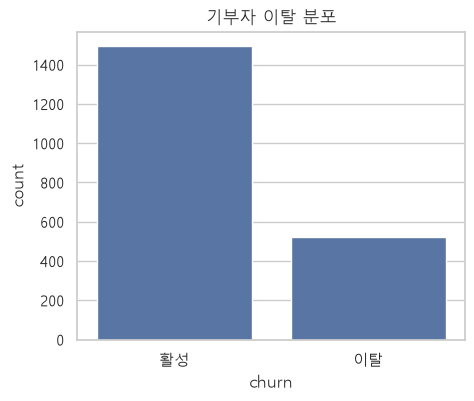

churn
0    0.741807
1    0.258193
Name: proportion, dtype: float64


In [97]:
plt.figure(figsize=(5, 4))
sns.countplot(x="churn", data=df_origin)
plt.xticks([0, 1], ["활성", "이탈"])
plt.title("기부자 이탈 분포")
plt.show()

print(df_origin["churn"].value_counts(normalize=True))

기부하는 인원 74.2%, 기부 이탈 인원 25.8% 

### 연속형 숫자 변수 
- 나이, 소득과 이탈 시각화

C:\Users\playdata2\AppData\Local\Temp\ipykernel_16420\2147799593.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["활성", "이탈"])
C:\Users\playdata2\AppData\Local\Temp\ipykernel_16420\2147799593.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["활성", "이탈"])


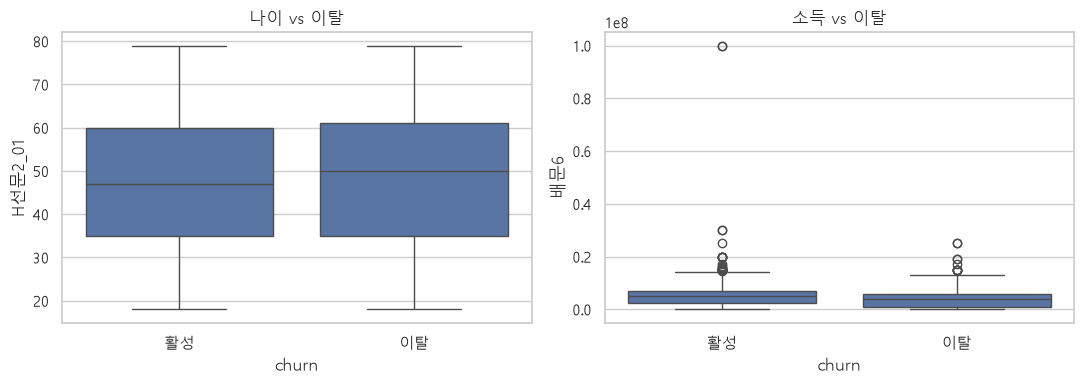

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="churn", y="H선문2_01", data=df_origin, ax=axes[0])
axes[0].set_xticklabels(["활성", "이탈"])
axes[0].set_title("나이 vs 이탈")

sns.boxplot(x="churn", y="배문6", data=df_origin, ax=axes[1])
axes[1].set_xticklabels(["활성", "이탈"])
axes[1].set_title("소득 vs 이탈")

plt.tight_layout()
plt.show()

나이 부분 : 기부하는 인원은 40~60대, 이탈인원 40~60대가 겹쳐있어서 나이로는 이탈 판단이 어려움  
소득 부분 : 활성 부분의 비이상적으로 1억인 부분이 있기 때문에 결측치 처리할 예정

나이와 소득 부분은 연속형 숫자 변수이므로 박스플롯 확인이 가능하여 박스플롯으로 확인

In [99]:
df_origin["배문6"].sort_values(ascending=False).head(20)

NO
2959     100000000
39377    100000000
69397     30000000
9290      30000000
57896     25000000
9039      25000000
5131      25000000
17246     20000000
28224     20000000
234       20000000
3510      20000000
9530      20000000
11399     19000000
9381      19000000
16382     17000000
2022      17000000
36353     16500000
4954      16000000
12787     15500000
2469      15300000
Name: 배문6, dtype: int64

배문6 : 월평균소득

75%     6,700,000원  
90%     9,000,000원  
95%    10,000,000원  
99%    15,000,000원  
99.5%  20,000,000원   ← 여기서부터 확 튀기 시작  
99.9%  75,280,500원  
max   100,000,000원  

### 소득 부분의 이상치를 다시 데이터 정제화 작업

In [100]:
# 1) 2천만 원 초과는 이상치로 보고 일단 결측(NaN)으로 바꿈
X.loc[X["배문6"] > 20000000, "배문6"] = np.nan
print("이상치로 처리된 개수:", X["배문6"].isnull().sum())

# 2) 결측치를 중앙값으로 채움
median_income = X["배문6"].median()
X["배문6"] = X["배문6"].fillna(median_income)

print(X["배문6"].describe())

이상치로 처리된 개수: 0
count    2.014000e+03
mean     4.631073e+06
std      3.574898e+06
min      5.000000e+01
25%      2.000000e+06
50%      4.500000e+06
75%      7.000000e+06
max      2.000000e+07
Name: 배문6, dtype: float64


In [101]:
print(selected.shape)          
selected.isnull().sum()        # 혹시 남은 결측치 있는지 체크

(2014, 23)


churn      0
선문1        0
H선문2_01    0
선문3        0
배문1        0
배문2        0
배문3        0
배문4        0
배문5        0
배문6        0
배문7        0
배문8        0
문7         0
문8         0
문30_1      0
문31        0
문32        0
문33_1      0
문33_2      0
문33_3      0
문40        0
문42        0
문44        0
dtype: int64

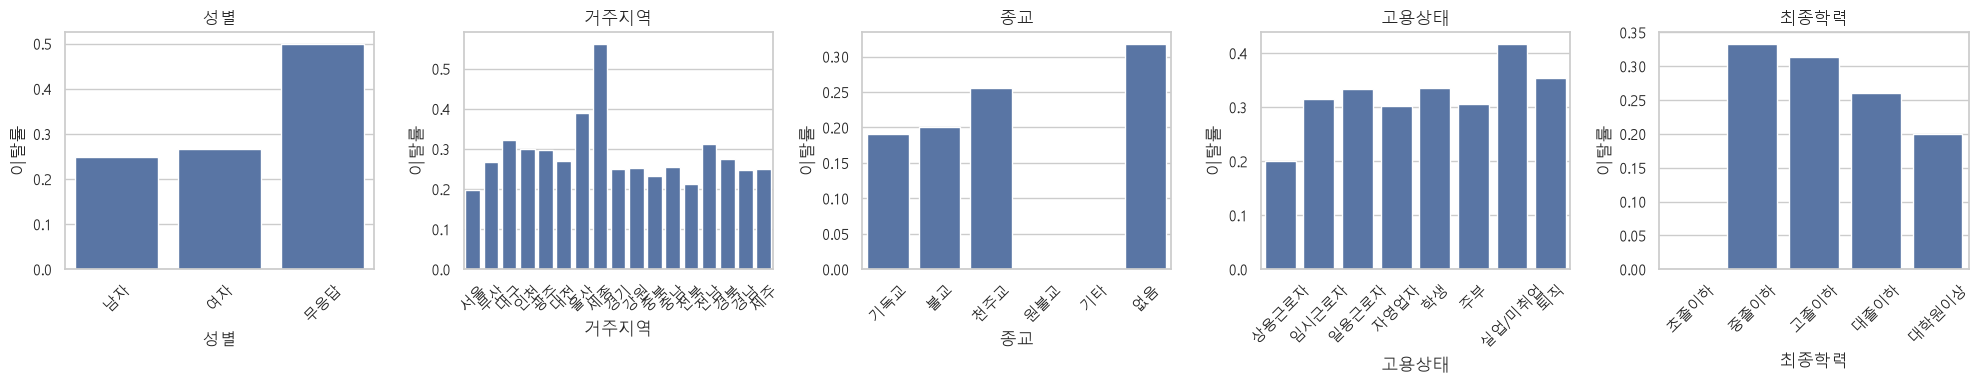

In [102]:
# 코드값 -> 실제 응답 텍스트로 바꾸는 매핑표
value_maps = {
    "성별": {1: "남자", 2: "여자", 3: "직접기입", 4: "무응답"},
    "거주지역": {
        1: "서울", 2: "부산", 3: "대구", 4: "인천", 5: "광주", 6: "대전", 7: "울산", 8: "세종",
        9: "경기", 10: "강원", 11: "충북", 12: "충남", 13: "전북", 14: "전남", 15: "경북", 16: "경남", 17: "제주",
    },
    "종교": {1: "기독교", 2: "불교", 3: "천주교", 4: "원불교", 9997: "기타", 9998: "없음"},
    "고용상태": {
        1: "상용근로자", 2: "임시근로자", 3: "일용근로자", 4: "자영업자",
        5: "학생", 6: "주부", 7: "실업/미취업", 8: "퇴직",
    },
    "최종학력": {1: "초졸이하", 2: "중졸이하", 3: "고졸이하", 4: "대졸이하", 5: "대학원이상"},
}

cat_cols_to_check = ["성별", "거주지역", "종교", "고용상태", "최종학력"]

fig, axes = plt.subplots(1, len(cat_cols_to_check), figsize=(4*len(cat_cols_to_check), 4))
for i, col in enumerate(cat_cols_to_check):
    rate = df_selected.groupby(col)["이탈여부"].mean()
    rate.index = rate.index.map(value_maps[col])   # 숫자 인덱스를 텍스트로 교체
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("이탈률")
    axes[i].tick_params(axis="x", rotation=45)      # 글자 겹치지 않게 45도 기울임
plt.tight_layout()
plt.show()

### 기부이탈률과 컬럼들의 상관관계


- 성별 : 남자, 여자 관계없이 이탈률은 비슷함
- 거주지역 : 특이하게 세종, 울산지역이 이탈률이 비교적 높게 나옴 (설문인원이 적어서 신뢰하기 어려울 수 있음)
- 종교 : 무종교가 이탈률이 높음
- 고용상태 : 다른 상태보다 실업/미취업 상태가 이탈률이 높음
- 최종학력 : 최종학력이 높을 수록 이탈률이 적어짐

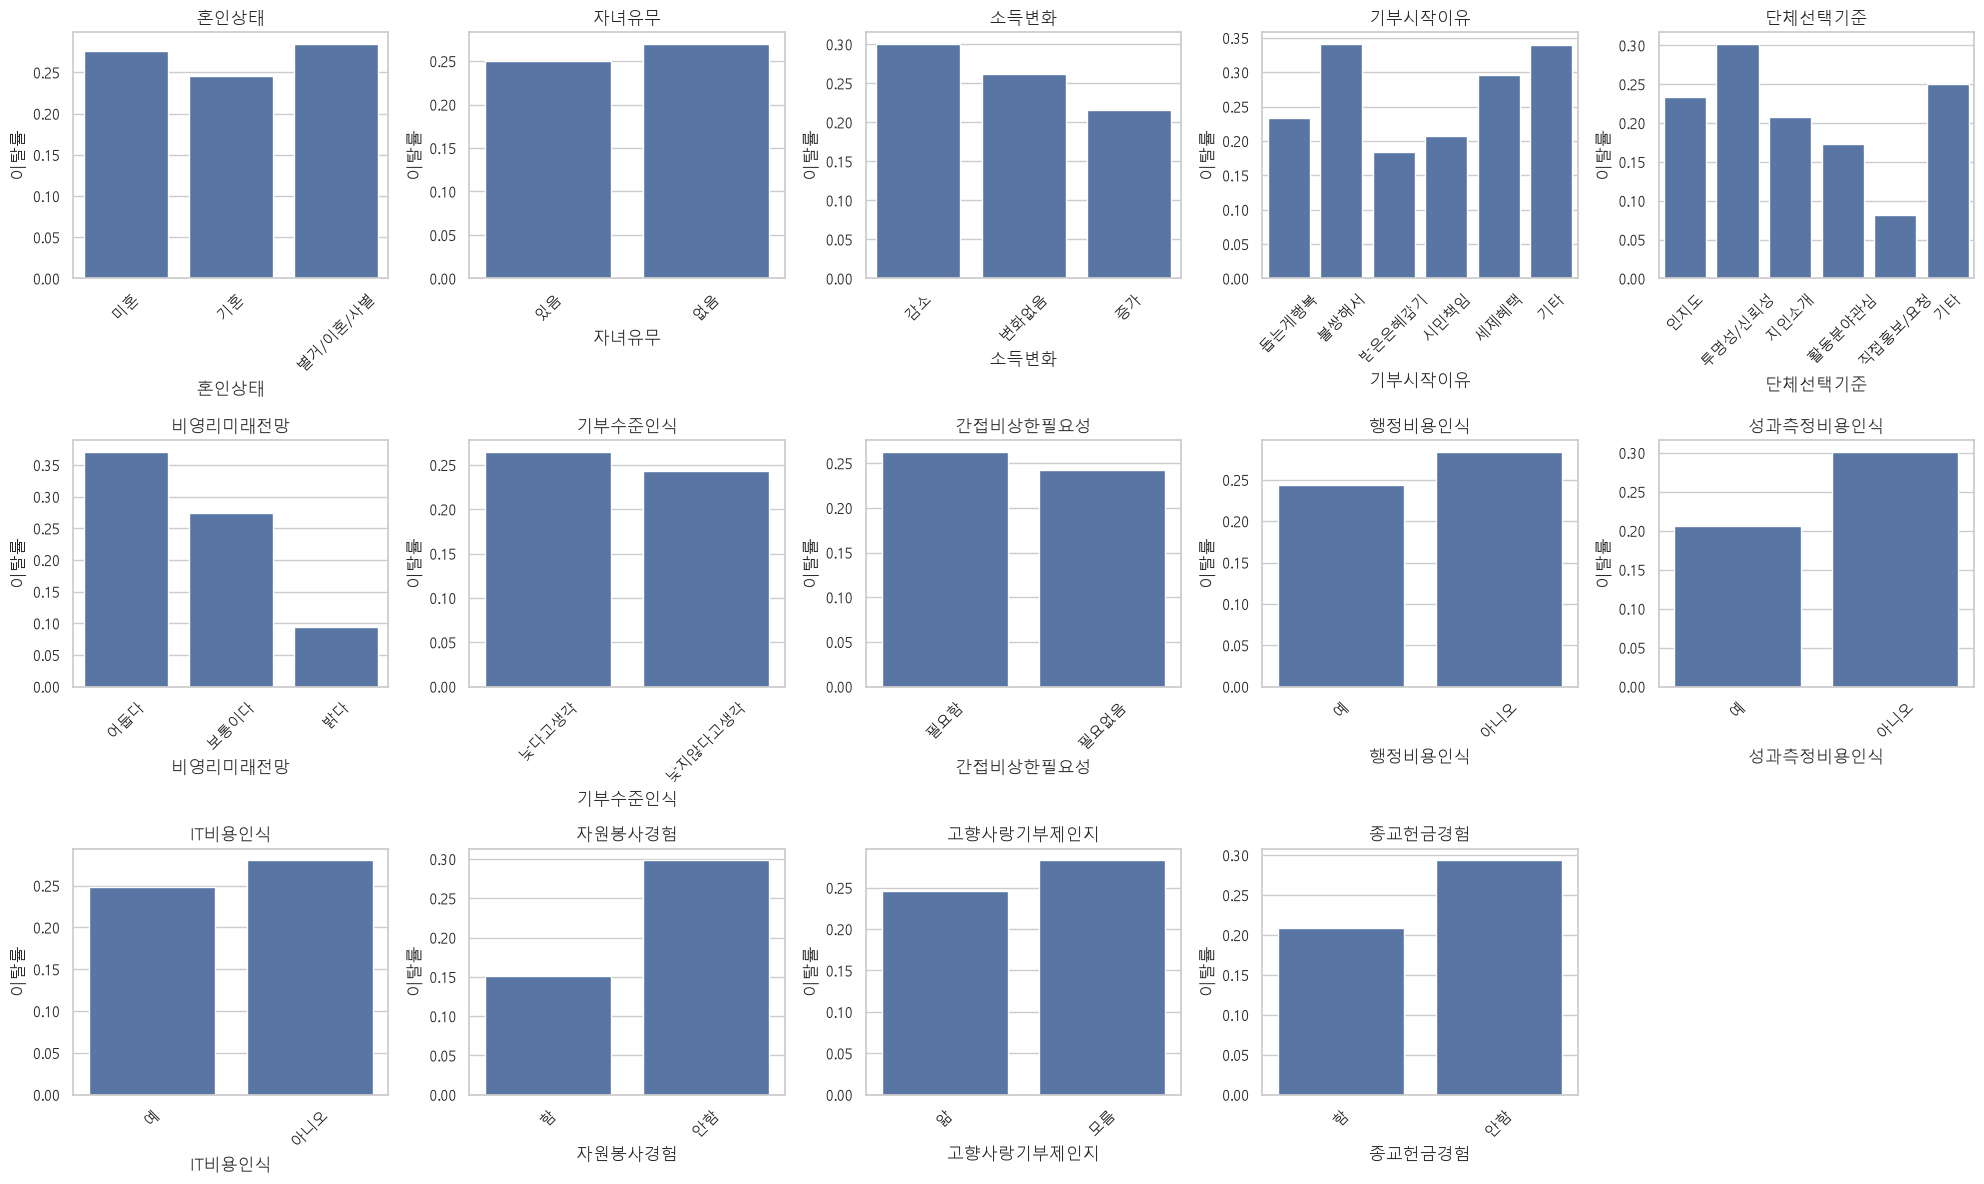

In [103]:
value_maps2 = {
    "혼인상태": {1: "미혼", 2: "기혼", 3: "별거/이혼/사별"},
    "자녀유무": {1: "있음", 2: "없음"},
    "소득변화": {1: "감소", 2: "변화없음", 3: "증가"},
    "기부시작이유": {
        1: "돕는게행복", 2: "불쌍해서", 3: "받은은혜갚기",
        4: "시민책임", 5: "세제혜택", 9997: "기타",
    },
    "단체선택기준": {
        1: "인지도", 2: "투명성/신뢰성", 3: "지인소개",
        4: "활동분야관심", 5: "직접홍보/요청", 9997: "기타",
    },
    "비영리미래전망": {1: "어둡다", 2: "보통이다", 3: "밝다"},
    "기부수준인식": {1: "낮다고생각", 2: "낮지않다고생각"},
    "간접비상한필요성": {1: "필요함", 2: "필요없음"},
    "행정비용인식": {1: "예", 2: "아니오"},
    "성과측정비용인식": {1: "예", 2: "아니오"},
    "IT비용인식": {1: "예", 2: "아니오"},
    "자원봉사경험": {1: "함", 2: "안함"},
    "고향사랑기부제인지": {1: "앎", 2: "모름"},
    "종교헌금경험": {1: "함", 2: "안함"},
}

remaining_cols = list(value_maps2.keys())
# 가구원수는 코드가 아니라 실제 숫자(명 수)라 매핑 없이 그대로 사용

n_cols = 5
n_rows = -(-len(remaining_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(remaining_cols):
    rate = df_selected.groupby(col)["이탈여부"].mean()
    rate.index = rate.index.map(value_maps2[col])
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("이탈률")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(remaining_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 기부 이탈률

- 혼인상태 : 기혼이 이탈률이 미혼, 기타 보다 낮음  
- 소득부분 : 감소하면 기부 이탈률 증가  
- 자원봉사경험 : 자원봉사 경험이 없는 사람이 이탈률이 높음
- 종교헌금경험 : 헌금 경험 없는 사람이 이탈률이 높음

기타
- 단체선택기준 : 투명성/ 신뢰성이 가장 높음
- 비영리미래전망 : 비영리 단체는 어둡게 보는 인식이 큼


### 최종칼럼 선택

거주지역, 종교, 고용상태, 최종학력, 혼인상태, 소득변화, 자원봉사경험, 종교헌금경험, 단체선택기준

9개 전부 범주형(카테고리)이므로 연속형, 범주형 나누지 않고 한 번에 원-핫 인코딩 진행


In [104]:
feature_cols_final = [
    "거주지역", "종교", "고용상태", "최종학력", "혼인상태",
    "소득변화", "자원봉사경험", "종교헌금경험", "단체선택기준",
]

# 9개 변수만 남긴 최종 데이터
final_selected = df_selected[["이탈여부"] + feature_cols_final]

# 전부 범주형 -> 한 번에 원-핫 인코딩
X = pd.get_dummies(final_selected.drop(columns=["이탈여부"]), columns=feature_cols_final, drop_first=True)

# 정답(이탈여부) 따로 빼내서 y에 저장
y = final_selected["이탈여부"]

print(X.shape)

(2014, 43)


In [105]:
# X와 y를 합쳐서 상관관계 계산
combined = X.copy()
combined["이탈여부"] = y

corr_with_churn = combined.corr(numeric_only=True)["이탈여부"].sort_values(ascending=False)
print(corr_with_churn)

이탈여부             1.000000
자원봉사경험_2         0.149682
단체선택기준_2.0       0.134307
종교_9998          0.126688
종교헌금경험_2         0.095781
고용상태_7           0.079227
거주지역_8           0.062224
고용상태_8           0.057837
최종학력_3           0.054919
고용상태_5           0.044069
거주지역_7           0.043496
고용상태_6           0.039281
거주지역_3           0.037043
고용상태_2           0.034328
고용상태_4           0.031032
거주지역_4           0.025859
거주지역_5           0.020391
고용상태_3           0.017624
거주지역_14          0.015768
혼인상태_3           0.014326
최종학력_2           0.011503
소득변화_2           0.010639
거주지역_15          0.007389
거주지역_2           0.006871
최종학력_4           0.006516
거주지역_6           0.005885
단체선택기준_9997.0   -0.001182
거주지역_12         -0.001396
거주지역_17         -0.001875
거주지역_10         -0.002040
종교_3            -0.002676
거주지역_16         -0.005405
거주지역_11         -0.008652
거주지역_9          -0.011595
거주지역_13         -0.017355
종교_4            -0.022787
단체선택기준_3.0      -0.022961
종교_9997         -0.026318
혼인상태_2      

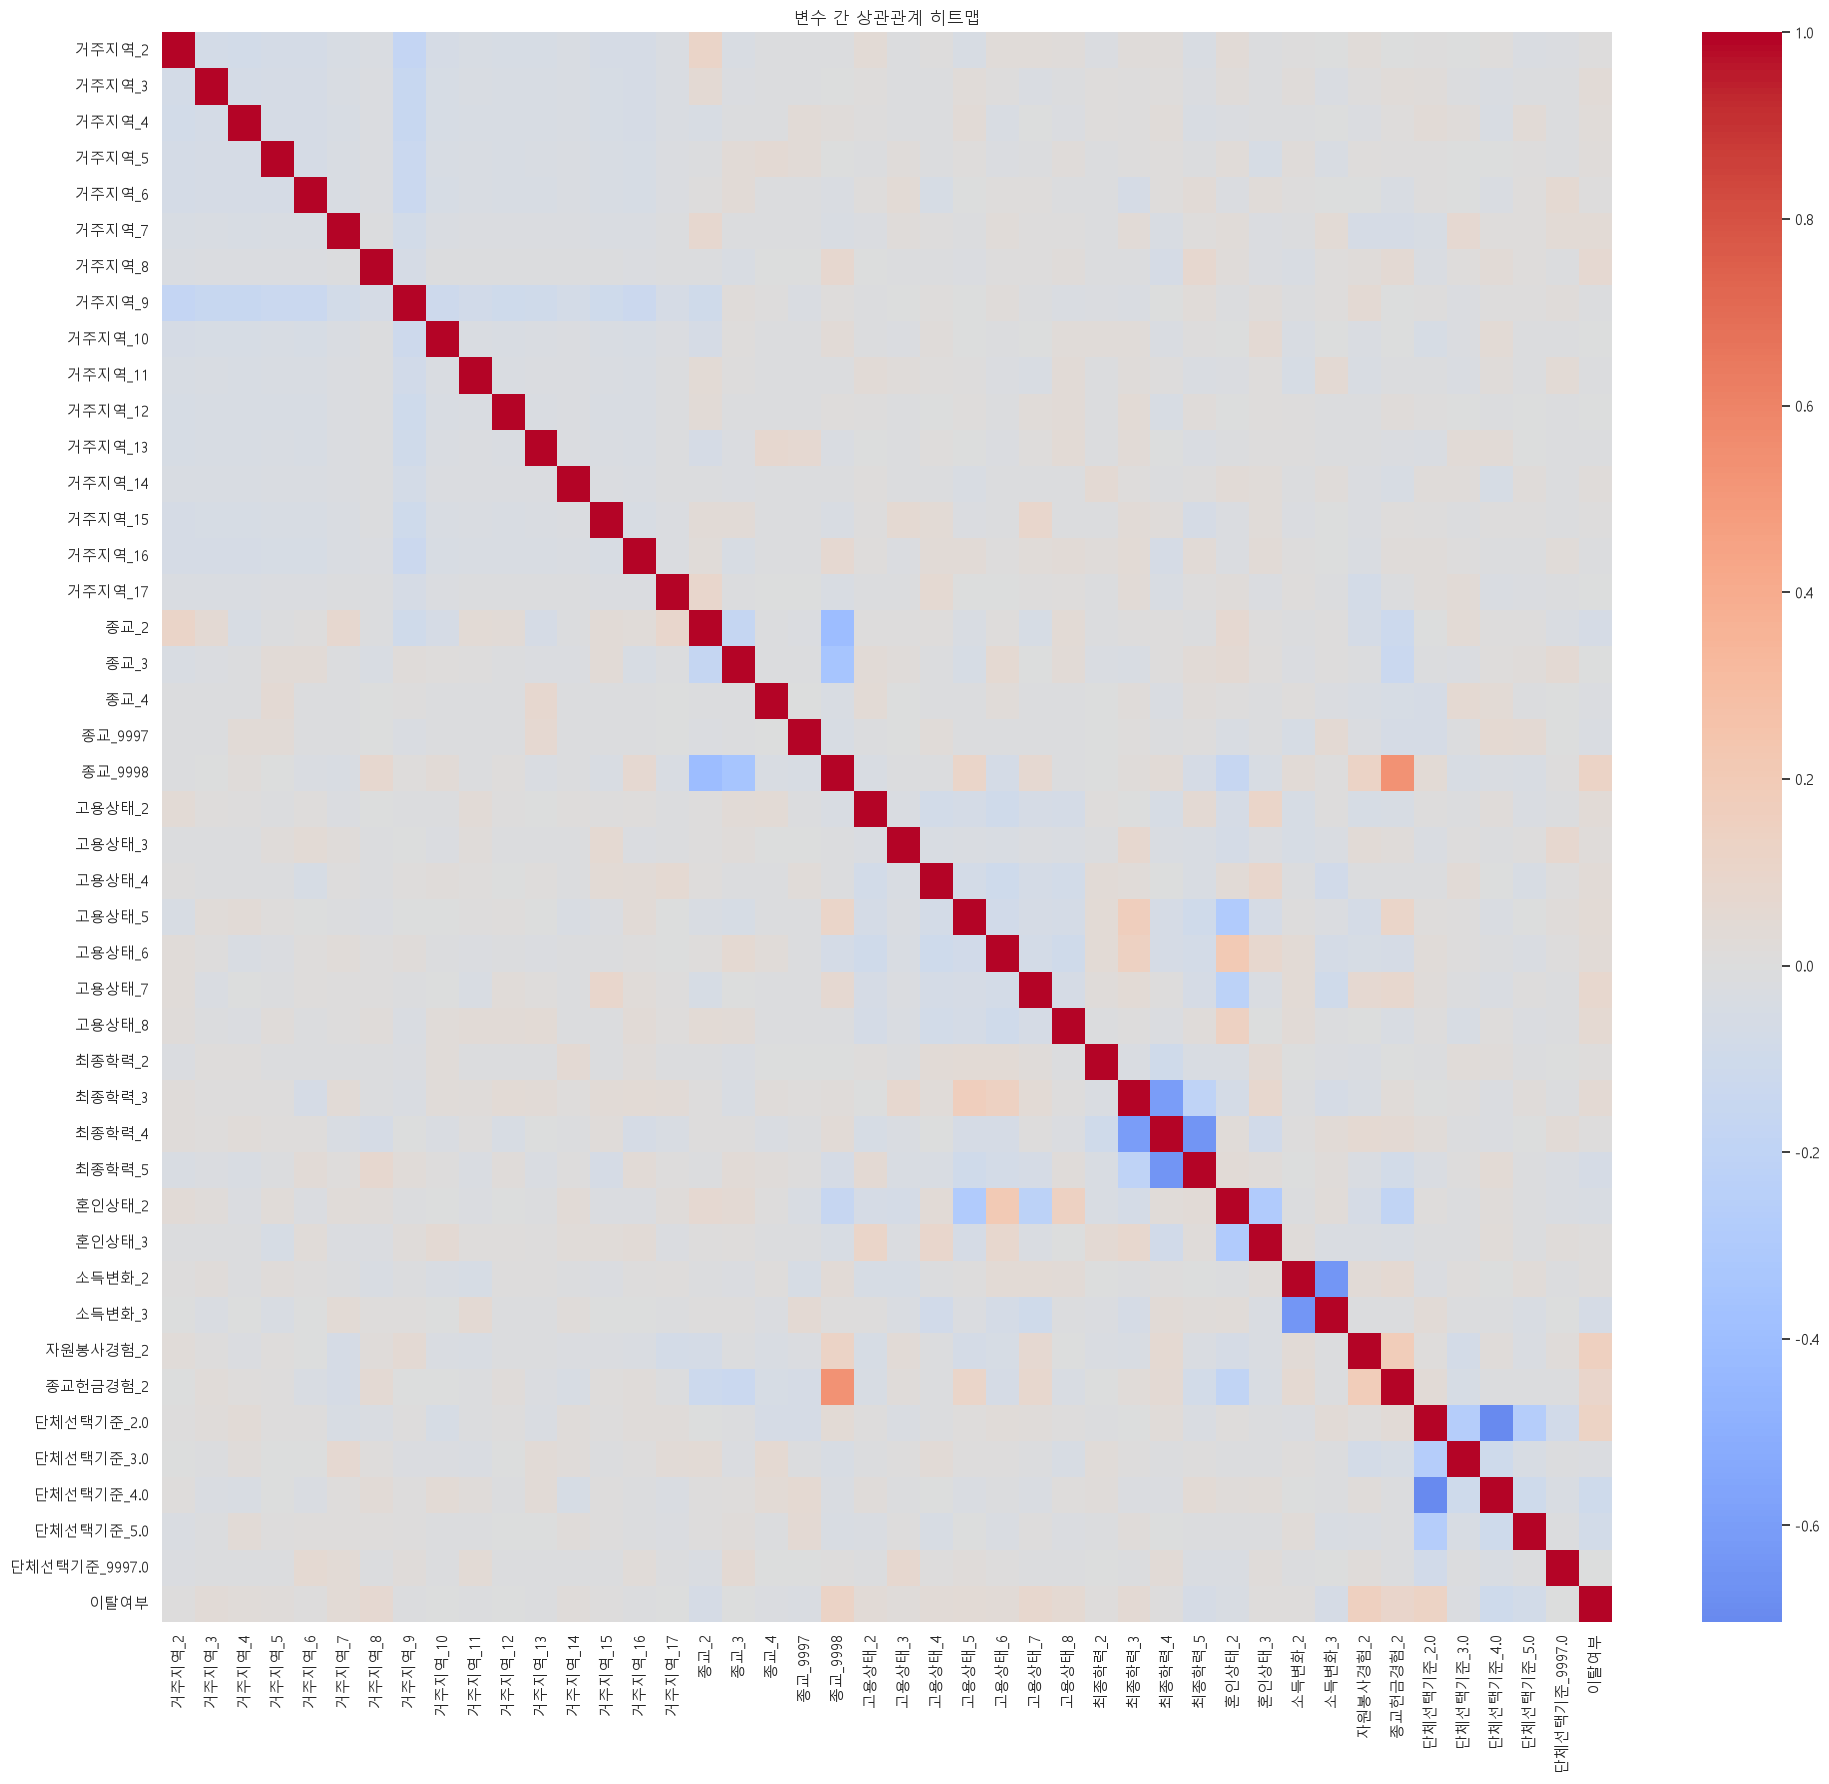

In [106]:
combined = X.copy()
combined["이탈여부"] = y

plt.figure(figsize=(20, 18))
corr = combined.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

컬럼이 많아서 히트맵으로는 보기 힘들어서 막대그래프로 상관관계 확인

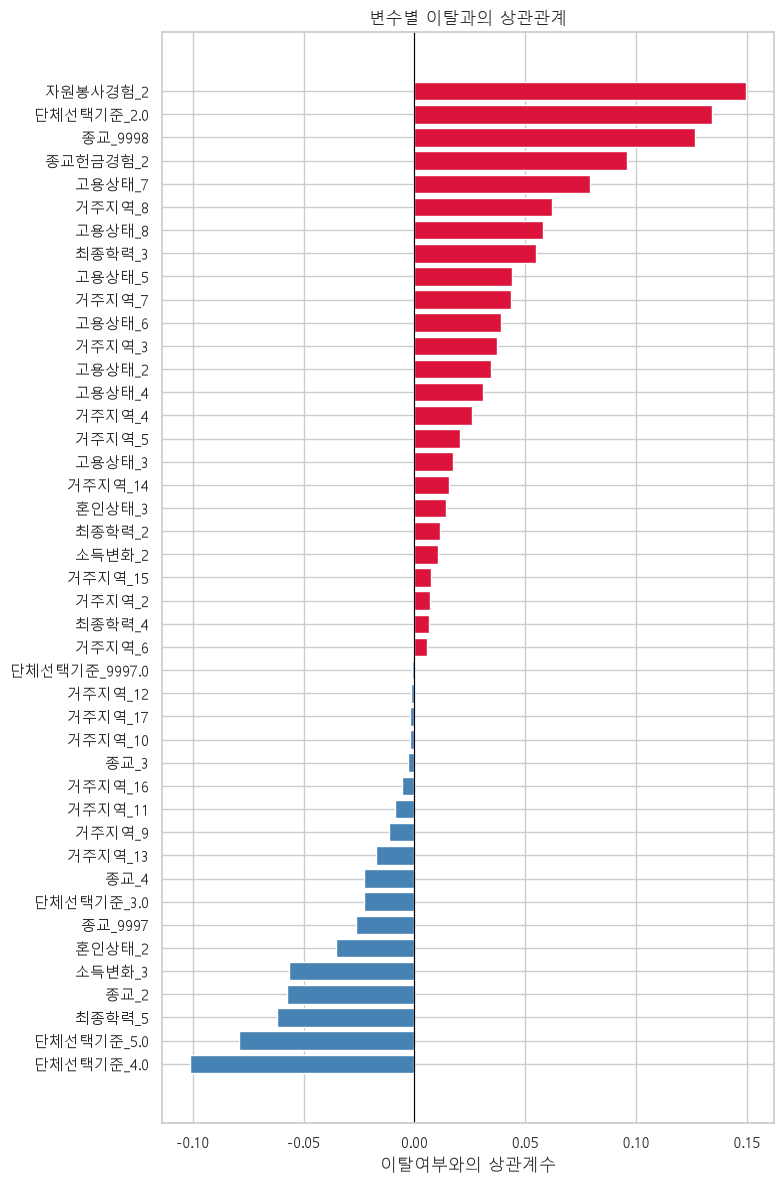

In [107]:
combined = X.copy()
combined["이탈여부"] = y

corr_with_churn = combined.corr(numeric_only=True)["이탈여부"].drop("이탈여부").sort_values()

plt.figure(figsize=(8, 12))
colors = ["crimson" if v > 0 else "steelblue" for v in corr_with_churn.values]
plt.barh(corr_with_churn.index, corr_with_churn.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("이탈여부와의 상관계수")
plt.title("변수별 이탈과의 상관관계")
plt.tight_layout()
plt.show()

자원봉사경험_2는 자원봉사경험이 없는 사람으로써 기부 이탈률과 가장 상관관계가 높은것으로 판단됨  
단체선택기준_4.0은 활동 분야나 수혜자에 대한 관심으로 관심이 많은 사람이 기부 이탈이 가장 적음   

### 4. 머신러닝 모델에 학습하기위한 데이터 전처리

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(1611, 43) (403, 43)
0.25822470515207946 0.25806451612903225


스케일링 작업은 별도로 진행하지 않음  
스케일링은 숫자 범위 차이가 큰 연속형 변수가 섞여있는 경우 하지만  
지금 있는 컬럼들은 0 ~ 1 사이값들 이므로 진행하지 않음

### 5. 머신러닝 모델 학습 및 예측

로지스틱 회귀

In [109]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [110]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 베이스라인: 무조건 "활성(0)"으로 찍었을 때 정확도
baseline_acc = (y_test == 0).mean()
print("베이스라인 정확도:", baseline_acc)

print(classification_report(y_test, y_pred, target_names=["활성", "이탈"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

베이스라인 정확도: 0.7419354838709677
              precision    recall  f1-score   support

          활성       0.75      0.95      0.84       299
          이탈       0.41      0.11      0.17       104

    accuracy                           0.73       403
   macro avg       0.58      0.53      0.50       403
weighted avg       0.66      0.73      0.67       403

ROC-AUC: 0.6747009261641368


베이스라인 정확도: 0.742  
모델 정확도:      0.73        ← 베이스라인보다 오히려 살짝 낮음  
이탈 재현율:      0.11        ← 이탈자 104명 중 11명만 맞춤 (89% 놓침)  
ROC-AUC:         0.675       ← 0.5(랜덤)보단 낫지만 그리 강하지 않음  

In [111]:
rf_model = RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["활성", "이탈"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

          활성       0.74      1.00      0.85       299
          이탈       0.00      0.00      0.00       104

    accuracy                           0.74       403
   macro avg       0.37      0.50      0.43       403
weighted avg       0.55      0.74      0.63       403

ROC-AUC: 0.6868568304605094


c:\Users\playdata2\SKN34-2nd-6Team\subvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\playdata2\SKN34-2nd-6Team\subvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\playdata2\SKN34-2nd-6Team\subvenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [112]:
rf_balanced = RandomForestClassifier(
    n_estimators=400, max_depth=8, random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)
y_proba_bal = rf_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_bal, target_names=["활성", "이탈"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

          활성       0.82      0.57      0.67       299
          이탈       0.34      0.65      0.45       104

    accuracy                           0.59       403
   macro avg       0.58      0.61      0.56       403
weighted avg       0.70      0.59      0.61       403

ROC-AUC: 0.6802321842037561


변수모델 9개로 이탈 예측은 어려움.  
따라서 AI의 추천에 따라 9개 -> 22개의 변수모델을 추가하여 다시 학습 및 예측을 진행

In [113]:
# 1) 22개 전체 안전 변수 목록 (인구통계 11개 + 태도 11개)
feature_cols_full = [
    "선문1", "H선문2_01", "선문3", "배문1", "배문2",
    "배문3", "배문4", "배문5", "배문6", "배문7", "배문8",
    "문7", "문8", "문30_1", "문31", "문32",
    "문33_1", "문33_2", "문33_3", "문40", "문42", "문44",
]

# 2) 소득(배문6) 이상치 처리 -- 잊지 말고 다시 적용!
df_origin.loc[df_origin["배문6"] > 20000000, "배문6"] = df_origin["배문6"].median()

# 3) churn + 22개 변수만 선택
selected_full = df_origin[["churn"] + feature_cols_full]

# 4) 연속형(나이, 소득)과 범주형 구분
continuous_cols = ["H선문2_01", "배문6"]
categorical_cols = [c for c in feature_cols_full if c not in continuous_cols]

# 5) 범주형만 원-핫 인코딩 (연속형은 그대로 둠)
X = pd.get_dummies(selected_full.drop(columns=["churn"]), columns=categorical_cols, drop_first=True)
y = selected_full["churn"]

print(X.shape)

(2014, 67)



--------------------------------------------------
[Logistic Regression]
--------------------------------------------------


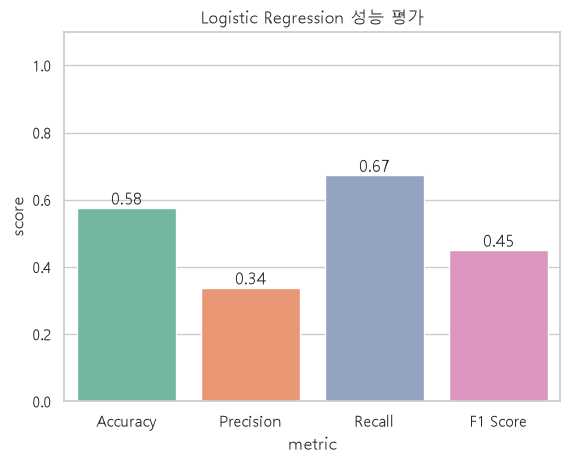


Confusion Matrix


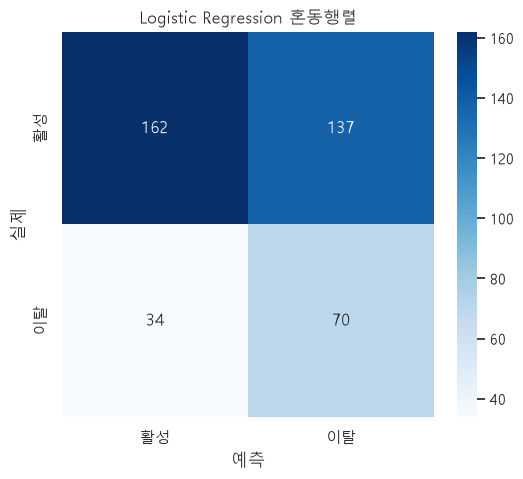


Classification Report
              precision    recall  f1-score   support

          활성       0.83      0.54      0.65       299
          이탈       0.34      0.67      0.45       104

    accuracy                           0.58       403
   macro avg       0.58      0.61      0.55       403
weighted avg       0.70      0.58      0.60       403


--------------------------------------------------
[Decision Tree]
--------------------------------------------------


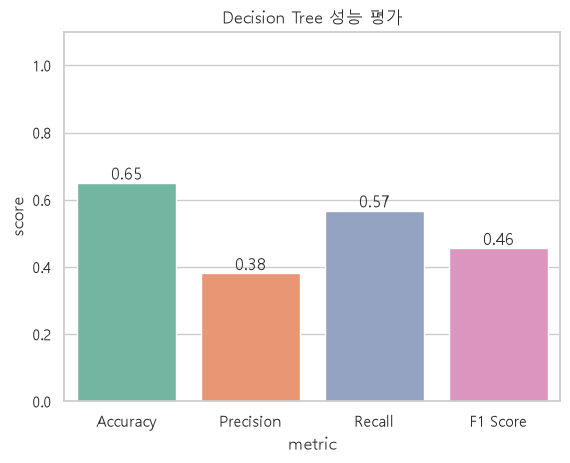


Confusion Matrix


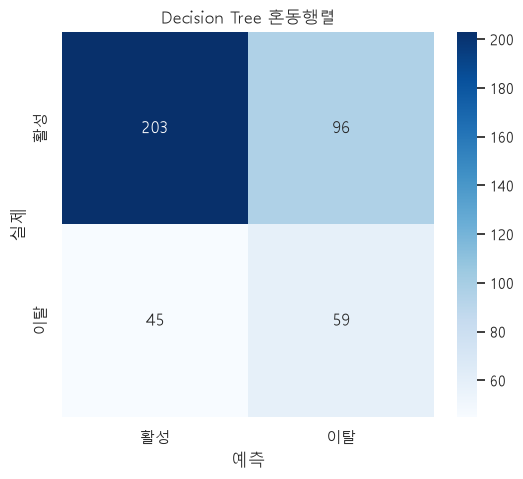


Classification Report
              precision    recall  f1-score   support

          활성       0.82      0.68      0.74       299
          이탈       0.38      0.57      0.46       104

    accuracy                           0.65       403
   macro avg       0.60      0.62      0.60       403
weighted avg       0.71      0.65      0.67       403


--------------------------------------------------
[Random Forest]
--------------------------------------------------


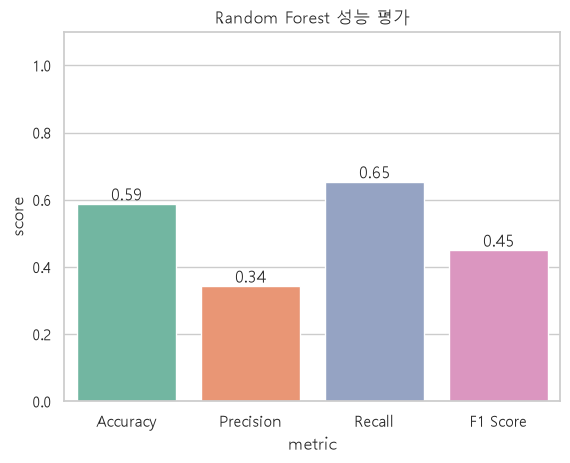


Confusion Matrix


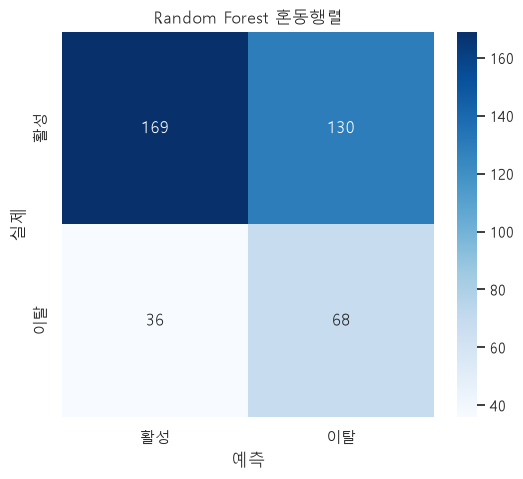


Classification Report
              precision    recall  f1-score   support

          활성       0.82      0.57      0.67       299
          이탈       0.34      0.65      0.45       104

    accuracy                           0.59       403
   macro avg       0.58      0.61      0.56       403
weighted avg       0.70      0.59      0.61       403


--------------------------------------------------
[XGBoost]
--------------------------------------------------


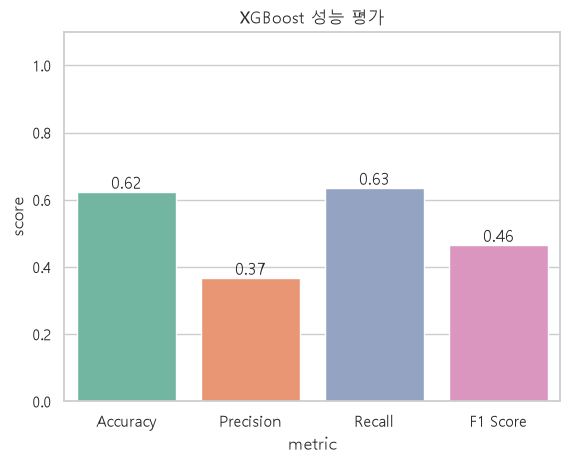


Confusion Matrix


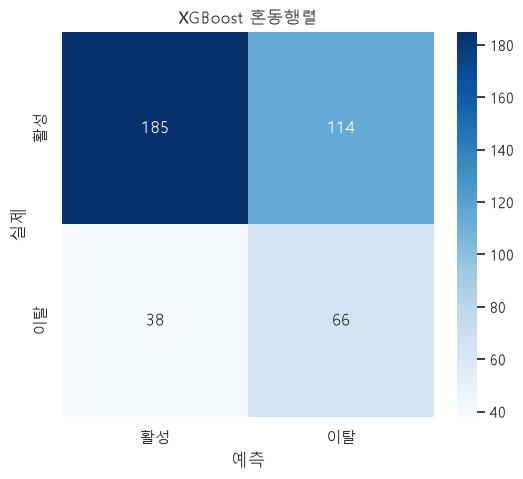


Classification Report
              precision    recall  f1-score   support

          활성       0.83      0.62      0.71       299
          이탈       0.37      0.63      0.46       104

    accuracy                           0.62       403
   macro avg       0.60      0.63      0.59       403
weighted avg       0.71      0.62      0.65       403

                 model  accuracy  precision    recall  f1_score
0  Logistic Regression  0.575682   0.338164  0.673077  0.450161
1        Decision Tree  0.650124   0.380645  0.567308  0.455598
2        Random Forest  0.588089   0.343434  0.653846  0.450331
3              XGBoost  0.622829   0.366667  0.634615  0.464789


In [114]:
# 1) 모델 준비 + 학습
scale = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=scale, random_state=42, eval_metric='logloss'),
}

for name, model in models.items():
    model.fit(X_train, y_train)   # evaluate_models 안에서는 학습을 안 하니, 여기서 미리 다 학습시켜둠


# 2) 평가 함수
def evaluate_models(models, X_test, y_test):
    results = []

    for name, pipe in models.items():
        # 예측
        y_pred = pipe.predict(X_test)

        # 평가 지표
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # 평가 결과 저장
        results.append({
            "model": name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

        # 출력
        print(f"\n{'-' * 50}")
        print(f"[{name}]")
        print(f"{'-' * 50}")

        # 모델별 평가 지표 시각화
        score_df = pd.DataFrame({
            "metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
            "score": [accuracy, precision, recall, f1]
        })

        ax = sns.barplot(
            data=score_df, x="metric", y="score",
            hue="metric", palette="Set2", legend=False
        )
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")

        plt.ylim(0, 1.1)
        plt.title(f"{name} 성능 평가")
        plt.show()

        print("\nConfusion Matrix")

        # 혼동행렬 시각화
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['활성', '이탈'], yticklabels=['활성', '이탈'])
        plt.xlabel("예측")
        plt.ylabel("실제")
        plt.title(f"{name} 혼동행렬")
        plt.show()

        print("\nClassification Report")
        print(classification_report(y_test, y_pred, target_names=['활성', '이탈']))

    return pd.DataFrame(results)


# 3) 실행
result_df = evaluate_models(models, X_test, y_test)
print(result_df)

### 6. 고도화

- 하이퍼파라미터 튜닝

In [115]:
from sklearn.model_selection import GridSearchCV

# 1) 탐색할 하이퍼파라미터 조합 정의
param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [1, 3, 5],
}

# 2) GridSearchCV: 모든 조합을 5-fold 교차검증으로 시도해서 제일 좋은 조합 찾기
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("교차검증 평균 ROC-AUC:", grid.best_score_)

# 3) 찾아낸 최적 모델로 최종 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["활성", "이탈"]))
print("테스트 ROC-AUC:", roc_auc_score(y_test, y_proba))

최적 파라미터: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 200}
교차검증 평균 ROC-AUC: 0.6476986847569597
              precision    recall  f1-score   support

          활성       0.83      0.54      0.65       299
          이탈       0.34      0.67      0.45       104

    accuracy                           0.58       403
   macro avg       0.58      0.61      0.55       403
weighted avg       0.70      0.58      0.60       403

테스트 ROC-AUC: 0.6783991510162078


## 분석 결과 및 결론

**모델 성능**
- 4개 모델(Logistic Regression, Decision Tree, Random Forest, XGBoost) 비교 결과, **Random Forest**의 성능이 가장 우수함
- ROC-AUC: **0.72**
  - 0.5(완전 무작위)보다는 확실히 나은 판별력을 보이지만, 완벽한 이탈자 구별에는 한계가 있음

**활용 방안**
- 관리자 입장에서는 모델 예측을 **"이탈/비이탈" 이분법적 판단**이 아닌, **"이탈 확률이 높은 사람"을 가려내는 도구**로 활용하는 것이 적절함
- 예: **이탈 확률 상위 20%에게 우선적으로 연락**하는 등, 한정된 리소스를 효율적으로 배분하는 우선순위 결정 방식으로 사용
